## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

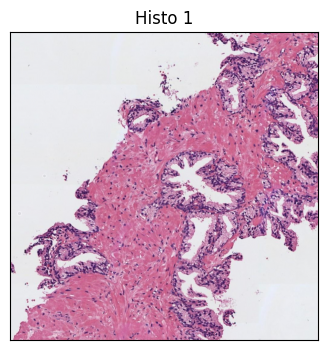

In [1]:
import math

from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from skimage import io
import numpy as np
import cv2

def get_imagen_original_normalizada(ruta_imagen):
    # Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
    img = io.imread(ruta_imagen)
    
    # Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
    rgb = img.copy()
    rgb_normalizada = rgb.astype('uint8')/255

    return rgb, rgb_normalizada

def visualizar_imagen(imagen, titulo):
    fig, axes = plt.subplots(1, 1, figsize=(10, 4))
    axes.imshow(imagen, cmap='gray');   
    axes.set_title(titulo);        
    axes.set_xticks([]); 
    axes.set_yticks([])
    axes.set_visible(True)
    plt.show()

histo_1, histo_1_normalizada = get_imagen_original_normalizada('./histo_1.jpg')
visualizar_imagen(histo_1_normalizada, "Histo 1")

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

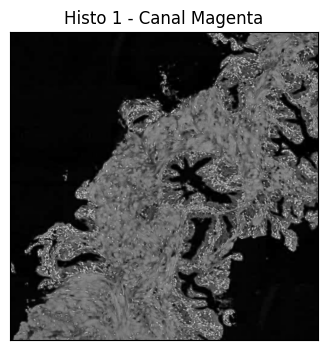

In [2]:
def obtener_CMYK(imagen_normalizada):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(imagen_normalizada, axis=2)
        C = (1-imagen_normalizada[:,:,0]-K)/(1-K)
        M = (1-imagen_normalizada[:,:,1]-K)/(1-K)
        Y = (1-imagen_normalizada[:,:,2]-K)/(1-K)
    
    CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
    C,M,Y,K = cv2.split(CMYK)
    return C,M,Y,K
    
    
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta
histo_1_C, histo_1_M, histo_1_Y, histo_1_K = obtener_CMYK(histo_1_normalizada)

visualizar_imagen(histo_1_M.astype('uint8'), 'Histo 1 - Canal Magenta')

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

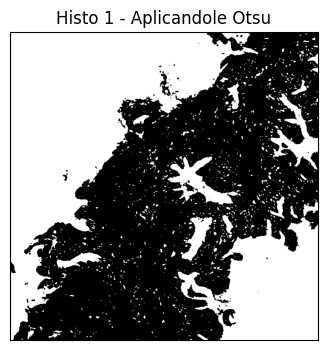

In [3]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

def transformar_imagen_a_float32(imagen):
  imagen_float_32 = imagen.astype(np.float32)
  return imagen_float_32


def aplicar_filtro_gauss_outsu_y_visualizar(imagen):
    imagen_32 = transformar_imagen_a_float32(imagen) # Se transforma a 32 float para poder escalar a grices con cv2.cvtColor
    imagen_32_gray = cv2.cvtColor(imagen_32, cv2.COLOR_BGR2GRAY)
    imagen_gray_u8 = (imagen_32_gray.astype(np.float32) * 255).clip(0, 255).astype(np.uint8) # Se pasa a u8 la escala de grises para poder graficar

    gaussian_blur = cv2.GaussianBlur(imagen_gray_u8, (5, 5), 0)
    _, gaussian_blur_mask = cv2.threshold(gaussian_blur, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_mask = cv2.threshold(gaussian_blur_mask, 0, 1, cv2.THRESH_OTSU)

    visualizar_imagen(otsu_mask, "Histo 1 - Aplicandole Otsu")

    return otsu_mask

histo_1_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_1_normalizada)

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

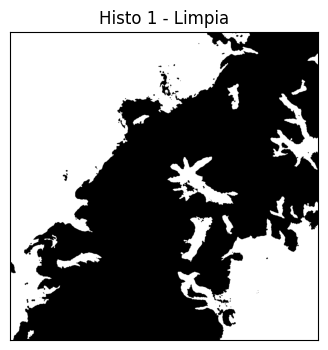

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante
from skimage.morphology import remove_small_objects

histo_1_bool = histo_1_otsu_mask.astype(bool)
histo_1_limpia = remove_small_objects(histo_1_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_1_limpia, "Histo 1 - Limpia")

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

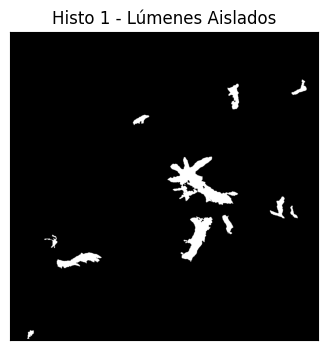

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 
from skimage.segmentation import clear_border 

def rellenar_fondo_2(imagen):
    # Crear una copia de la imagen
    imagen_copia = imagen.copy()
    
    # Definir una imagen negra de referencia
    h, w = imagen.shape
    ref = np.zeros((h+2, w+2), np.uint8)
    
    # Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (0, 0), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    # Fijar la semilla. En este caso en la esquina inferior derecha (posición 0,0) para rellenar a partir de ahí
    cv2.floodFill(imagen_copia, ref, (h - 1, w - 1), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

    return imagen_copia

def rellenar_fondo(imagen):
    imagen_copia = imagen.copy()
    mascara = imagen_copia.astype(bool)

    return clear_border(mascara).astype(np.uint8)
    
    


    
histo_1_lumenes = rellenar_fondo(histo_1_limpia)
visualizar_imagen(histo_1_lumenes, "Histo 1 - Lúmenes Aislados")

#### 5) Rellenar los objetos de los lúmenes

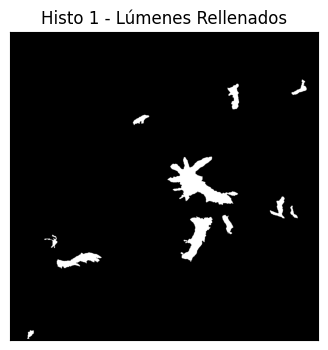

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante
from  scipy.ndimage import binary_fill_holes

histo_1_lumenes_fill = binary_fill_holes(histo_1_lumenes.copy())
visualizar_imagen(histo_1_lumenes_fill, "Histo 1 - Lúmenes Rellenados")

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

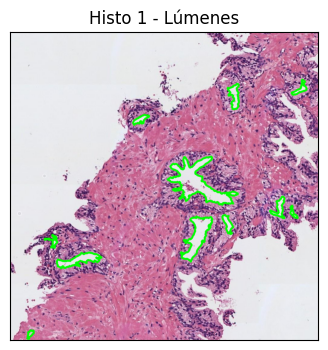

In [7]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

def contornear_lumenes(imagen_mascara, imagen_original):
    imagen = imagen_original.copy()
    
    contours, _ = cv2.findContours(imagen_mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) # Encontramos los contornos en una máscara
    imagen = cv2.drawContours(imagen, contours, -1, (0,255,0), 5) # Dibujamos los contornos

    return imagen

histo_1_con_contorno = contornear_lumenes(imagen_mascara = histo_1_lumenes_fill.astype(np.uint8), imagen_original= histo_1)
visualizar_imagen(histo_1_con_contorno, "Histo 1 - Lúmenes")

#### 7) Identificar y cropear el lumen más grande

El lumen 4 tiene el mayor área: 13367.0


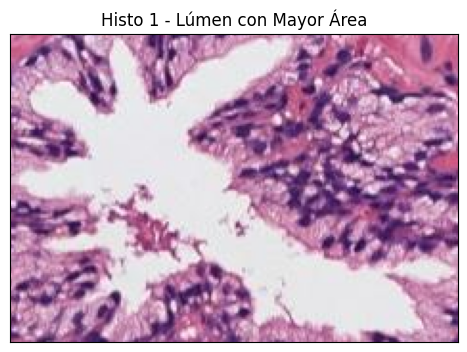

In [8]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.
from skimage.measure import label, regionprops

def obtener_propiedades_lumenes(etiquetas, num_etiquetas):

    propiedades = []

    for i in range(1, num_etiquetas + 1):
        lumen = etiquetas == i
        prop = regionprops(lumen.astype(np.uint8))

        propiedad = {
            "Nombre": f"Lumen {i}",
            "Área": np.round(prop[0].area, 4),
            "Área de la bounding box": np.round(prop[0].bbox_area, 4),
            "Área convexa": np.round(prop[0].convex_area, 4),
            "Exentricidad": np.round(prop[0].eccentricity, 4),
            "Diámetro equivalente": np.round(prop[0].equivalent_diameter, 4),
            "Extensión": np.round(prop[0].extent, 4),
            "Diámetro Feret": np.round(prop[0].feret_diameter_max, 4),
            "Longitud del eje mayor": np.round(prop[0].major_axis_length, 4),
            "Longitud del eje menor": np.round(prop[0].minor_axis_length, 4),
            "Orientación": np.round(prop[0].orientation, 4),
            "Perímetro": np.round(prop[0].perimeter, 4),
            "Solidez": np.round(prop[0].solidity, 4),
            "Compacidad": np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4),
        }
        
        propiedades.append(propiedad)

    return propiedades

def get_posicion_lumen_con_mayor_area(propiedades):
    areas = np.array([prop["Área"] for prop in propiedades])
    posicion = areas.argmax() + 1
    print(f"El lumen {posicion} tiene el mayor área: {areas.max()}")

    return posicion

def crop_lumen(posicion, imagen, etiquetas):
    lumen = etiquetas == posicion
    prop = regionprops(lumen.astype(np.uint8))
    minr, minc, maxr, maxc = prop[0].bbox
    return imagen[minr:maxr, minc:maxc]


histo_1_etiquetas, histo_1_num_etiquetas = label(histo_1_lumenes_fill, return_num=True) 
histo_1_propiedades = obtener_propiedades_lumenes(histo_1_etiquetas, histo_1_num_etiquetas)

posicion_lumen_con_mayor_area_histo_1 = get_posicion_lumen_con_mayor_area(histo_1_propiedades)
histo_1_crop = crop_lumen(posicion_lumen_con_mayor_area_histo_1, histo_1, histo_1_etiquetas)
visualizar_imagen(histo_1_crop, "Histo 1 - Lúmen con Mayor Área")

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [9]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

def tabular_informacion(posicion_lumen, propiedades):
    prop = propiedades[posicion_lumen - 1]
    html_table = tabulate([prop], headers="keys", tablefmt="html")
    display(HTML(html_table))

tabular_informacion(posicion_lumen_con_mayor_area_histo_1, histo_1_propiedades)

Nombre,Área,Área de la bounding box,Área convexa,Exentricidad,Diámetro equivalente,Extensión,Diámetro Feret,Longitud del eje mayor,Longitud del eje menor,Orientación,Perímetro,Solidez,Compacidad
Lumen 4,13367,37674,27468,0.8443,130.458,0.3548,243.463,231.451,124.033,0.9965,1159.73,0.4866,0.1249


## Se Repite el Proceso con la Segunda Imagen

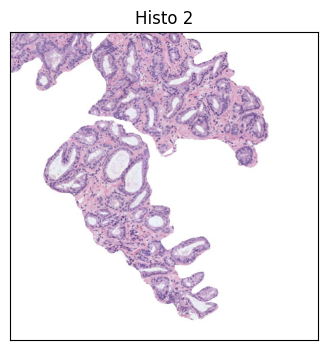

In [10]:
histo_2, histo_2_normalizada = get_imagen_original_normalizada('./histo_2.jpg')
visualizar_imagen(histo_2_normalizada, "Histo 2")

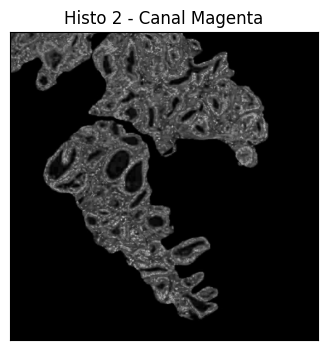

In [11]:
histo_2_C, histo_2_M, histo_2_Y, histo_2_K = obtener_CMYK(histo_2_normalizada)
visualizar_imagen(histo_2_M.astype('uint8'), 'Histo 2 - Canal Magenta')

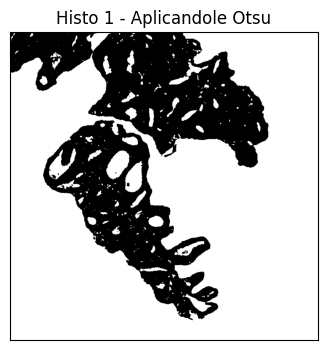

In [12]:
histo_2_otsu_mask = aplicar_filtro_gauss_outsu_y_visualizar(histo_2_normalizada)

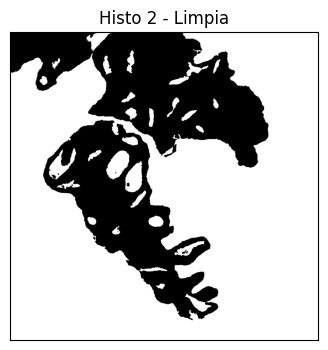

In [13]:
histo_2_bool = histo_2_otsu_mask.astype(bool)
histo_2_limpia = remove_small_objects(histo_2_bool, min_size=301).astype(np.uint8)
visualizar_imagen(histo_2_limpia, "Histo 2 - Limpia")

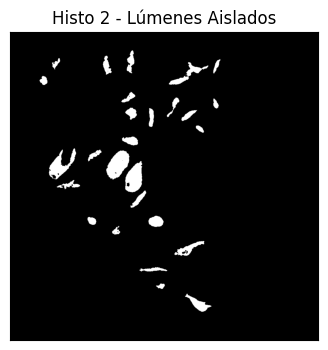

In [14]:
histo_2_lumenes = rellenar_fondo(histo_2_limpia)
visualizar_imagen(histo_2_lumenes, "Histo 2 - Lúmenes Aislados")

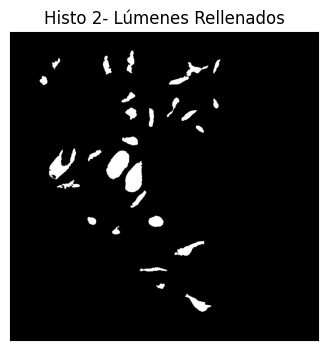

In [15]:
histo_2_lumenes_fill = binary_fill_holes(histo_2_lumenes.copy())
visualizar_imagen(histo_2_lumenes_fill, "Histo 2- Lúmenes Rellenados")

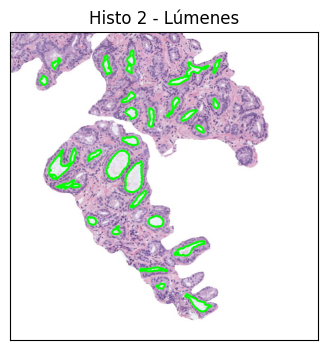

In [16]:
histo_2_etiquetas, histo_2_num_etiquetas = label(histo_2_lumenes_fill, return_num=True)
histo_2_con_contorno = contornear_lumenes(imagen_mascara = histo_2_lumenes_fill.astype(np.uint8), imagen_original= histo_2)
visualizar_imagen(histo_2_con_contorno, "Histo 2 - Lúmenes")

El lumen 17 tiene el mayor área: 4683.0


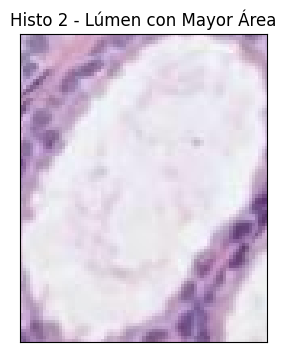

In [17]:
histo_2_propiedades = obtener_propiedades_lumenes(histo_2_etiquetas, histo_2_num_etiquetas)

posicion_lumen_con_mayor_area_histo_2 = get_posicion_lumen_con_mayor_area(histo_2_propiedades)
histo_2_crop = crop_lumen(posicion_lumen_con_mayor_area_histo_2, histo_2, histo_2_etiquetas)
visualizar_imagen(histo_2_crop, "Histo 2 - Lúmen con Mayor Área")

In [18]:
tabular_informacion(posicion_lumen_con_mayor_area_histo_2, histo_2_propiedades)

Nombre,Área,Área de la bounding box,Área convexa,Exentricidad,Diámetro equivalente,Extensión,Diámetro Feret,Longitud del eje mayor,Longitud del eje menor,Orientación,Perímetro,Solidez,Compacidad
Lumen 17,4683,7392,4884,0.8377,77.2177,0.6335,104.317,104.778,57.2181,-0.5628,288.149,0.9588,0.7088
